# XGBoost Long-Short Strategy — Analysis

Comparing two portfolio constructions on **identical model predictions**:
- **B · Rank-weight VW** — conviction-weighted, capped value-weight, no look-ahead leak
- **C · Rank-weight VW + Leg Balance** — same as B plus inverse-vol book scaling

Half-life variants: `hlinf` (no decay), `hl120` (10-year recency), and `hl60` (5-year recency).

In [262]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import spearmanr

ROOT   = Path("../data/backtest")
HLINF  = ROOT / "xgboost_ab_hlinf"
HL120  = ROOT / "xgboost_ab_hl120"
HL60   = ROOT / "xgboost_ab_hl60"
BENCH  = ROOT / "benchmark"

plt.rcParams.update({"figure.dpi": 130, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 10})

In [263]:
def load_run(folder):
    B = pd.read_csv(folder / "monthly_returns_B_rankw_vw.csv",           parse_dates=["eom"])
    C = pd.read_csv(folder / "monthly_returns_C_rankw_vw_balanced.csv",  parse_dates=["eom"])
    return B.set_index("eom").sort_index(), C.set_index("eom").sort_index()

Binf, Cinf = load_run(HLINF)
B120, C120 = load_run(HL120)
B60,  C60  = load_run(HL60)
MKT = pd.read_csv(BENCH / "monthly_returns.csv", parse_dates=["eom"]).set_index("eom").sort_index()

print(f"B hlinf: {Binf.index[0].date()} → {Binf.index[-1].date()}  ({len(Binf)} months)")
print(f"B hl120: {B120.index[0].date()} → {B120.index[-1].date()}  ({len(B120)} months)")
print(f"C hl120: {C120.index[0].date()} → {C120.index[-1].date()}  ({len(C120)} months)")
print(f"B hl60 : {B60.index[0].date()} → {B60.index[-1].date()}   ({len(B60)} months)")

B hlinf: 1986-01-31 → 2025-10-31  (478 months)
B hl120: 1986-01-31 → 2025-10-31  (478 months)
C hl120: 1986-01-31 → 2025-10-31  (478 months)
B hl60 : 1986-01-31 → 2025-10-31   (478 months)


## 1 · Performance Summary

In [264]:
def perf(s, label=""):
    s = s.dropna()
    ann_ret  = s.mean() * 12
    ann_vol  = s.std()  * np.sqrt(12)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum      = (1 + s).cumprod()
    max_dd   = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar   = ann_ret / abs(max_dd) if max_dd < 0 else np.nan
    win_rt   = (s > 0).mean()
    skew     = float(s.skew())
    max_ret  = float(s.max())
    min_ret  = float(s.min())
    return {"label": label, "ann_ret": ann_ret, "ann_vol": ann_vol,
            "sharpe": sharpe, "max_dd": max_dd, "calmar": calmar,
            "win_rate": win_rt, "skew": skew,
            "max_ret": max_ret, "min_ret": min_ret, "n": len(s)}

rows = [
    perf(Binf["net_qspread"], "B hlinf (rank-VW)"),
    perf(Cinf["net_qspread"], "C hlinf (rank-VW + leg-balance)"),
    perf(B120["net_qspread"], "B hl120 (rank-VW)"),
    perf(C120["net_qspread"], "C hl120 (rank-VW + leg-balance)"),
    perf(B60["net_qspread"],  "B hl60  (rank-VW)"),
    perf(C60["net_qspread"],  "C hl60  (rank-VW + leg-balance)"),
    perf(MKT["mkt_vw_lcl"],  "Market VW (benchmark)"),
]
summary = pd.DataFrame(rows).set_index("label")
cols = ["ann_ret","ann_vol","sharpe","max_dd","calmar","win_rate","skew","max_ret","min_ret","n"]
out = summary[cols].copy()
for c in ["ann_ret","ann_vol","max_dd","win_rate","max_ret","min_ret"]:
    out[c] = out[c].map("{:.2%}".format)
for c in ["sharpe","skew"]:
    out[c] = out[c].map("{:.3f}".format)
out["calmar"] = out["calmar"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "nan")
out["n"]      = out["n"].map("{:.0f}".format)
print("Full-sample net performance\n")
print(out.to_string())

Full-sample net performance

                                ann_ret ann_vol sharpe   max_dd calmar win_rate    skew max_ret  min_ret    n
label                                                                                                        
B hlinf (rank-VW)                11.40%  17.66%  0.645  -41.47%   0.27   57.53%   1.027  34.15%  -25.63%  478
C hlinf (rank-VW + leg-balance)   9.76%  14.05%  0.695  -32.64%   0.30   57.53%   0.669  24.70%  -19.27%  478
B hl120 (rank-VW)                12.04%  17.83%  0.675  -39.99%   0.30   57.11%   1.053  33.69%  -21.54%  478
C hl120 (rank-VW + leg-balance)  10.21%  14.15%  0.722  -30.50%   0.33   56.90%   0.691  24.64%  -16.16%  478
B hl60  (rank-VW)                12.14%  18.28%  0.664  -32.99%   0.37   57.74%   1.094  33.63%  -25.42%  478
C hl60  (rank-VW + leg-balance)  10.05%  14.42%  0.697  -28.46%   0.35   57.74%   0.713  24.34%  -19.17%  478
Market VW (benchmark)            12.53%  15.64%  0.802  -50.19%   0.25   65.97%  -0.633  17

## 2 · Sub-period Sharpe (by decade + trailing windows)

In [265]:
def subperiod(s, label):
    rows = []
    for dec in sorted({(y // 10) * 10 for y in s.index.year}):
        sub = s[(s.index.year >= dec) & (s.index.year < dec + 10)].dropna()
        if len(sub) < 6: continue
        rows.append({"period": f"{dec}s", "sharpe": sub.mean()/sub.std()*np.sqrt(12),
                     "ann_ret": sub.mean()*12, "n": len(sub)})
    for w in (60, 120):
        sub = s.iloc[-w:].dropna()
        rows.append({"period": f"last_{w}m", "sharpe": sub.mean()/sub.std()*np.sqrt(12),
                     "ann_ret": sub.mean()*12, "n": len(sub)})
    sub = s.dropna()
    rows.append({"period": "FULL", "sharpe": sub.mean()/sub.std()*np.sqrt(12),
                 "ann_ret": sub.mean()*12, "n": len(sub)})
    return pd.DataFrame(rows).set_index("period").rename(
        columns={"sharpe": f"SR_{label}", "ann_ret": f"ret_{label}", "n": f"n_{label}"})

tbl = pd.concat([
    subperiod(Binf["net_qspread"], "Binf"),
    subperiod(Cinf["net_qspread"], "Cinf"),
    subperiod(B120["net_qspread"], "B120"),
    subperiod(C120["net_qspread"], "C120"),
    subperiod(B60["net_qspread"],  "B60"),
    subperiod(C60["net_qspread"],  "C60"),
], axis=1)
sr_cols = [c for c in tbl.columns if c.startswith("SR")]
print("Net Sharpe by decade and trailing window\n")
print(tbl[sr_cols].round(3).to_string())

Net Sharpe by decade and trailing window

           SR_Binf  SR_Cinf  SR_B120  SR_C120  SR_B60  SR_C60
period                                                       
1980s        0.827    0.820    0.818    0.818   0.802   0.803
1990s        1.337    1.416    1.479    1.544   1.602   1.650
2000s        0.826    0.787    0.818    0.775   0.800   0.747
2010s        0.537    0.587    0.556    0.594   0.280   0.298
2020s       -0.371   -0.433   -0.278   -0.356  -0.139  -0.233
last_60m    -0.020   -0.105    0.030   -0.064  -0.019  -0.109
last_120m   -0.110   -0.109    0.011    0.007  -0.069  -0.111
FULL         0.645    0.695    0.675    0.722   0.664   0.697


## 3 · Cumulative Returns

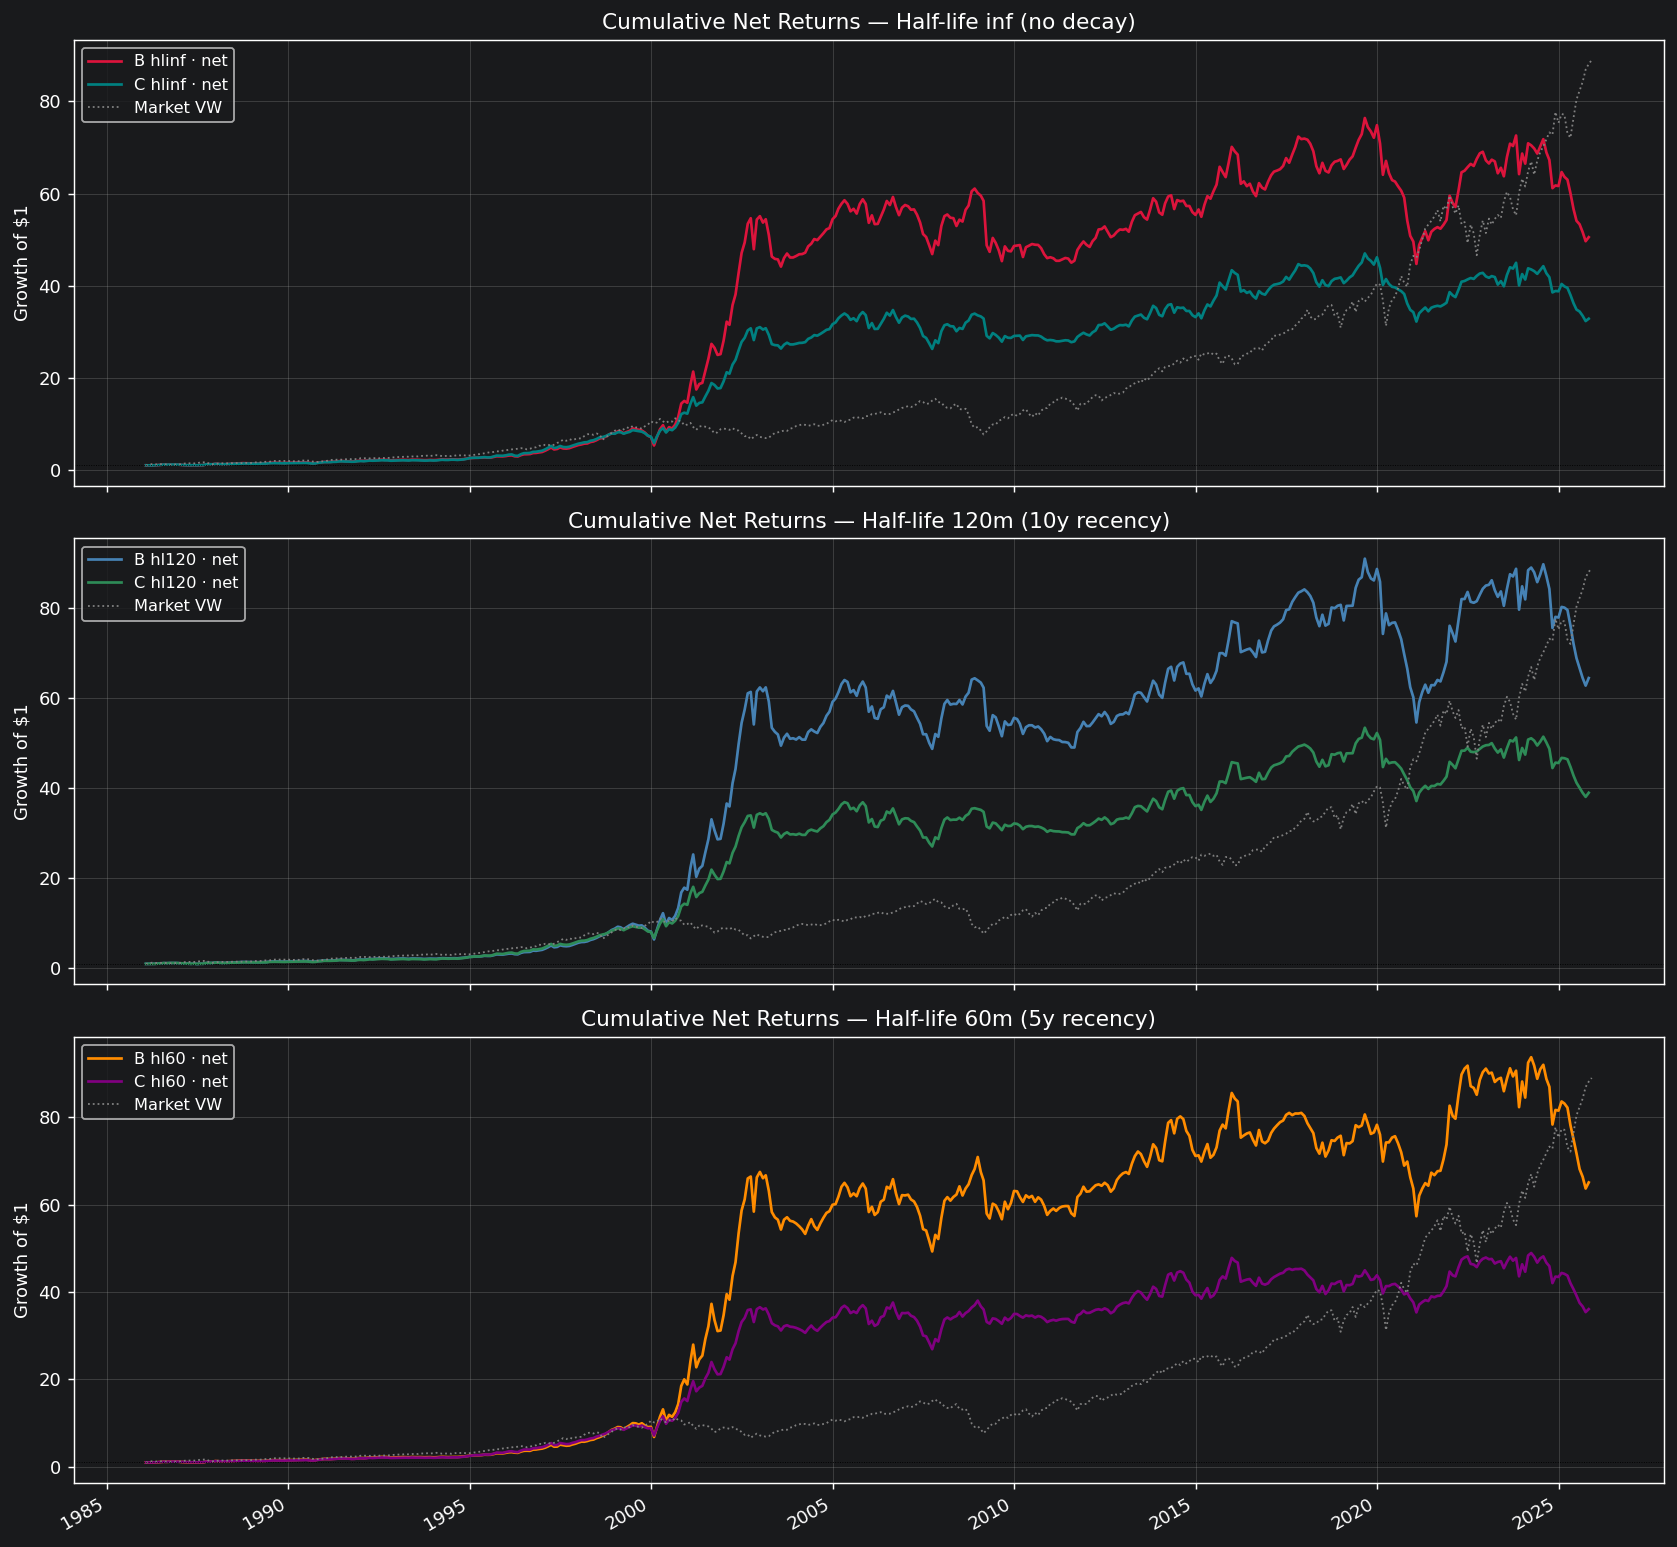

In [266]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

def cum(s): return (1 + s.dropna()).cumprod()

# top: hlinf
ax = axes[0]
ax.plot(cum(Binf["net_qspread"]), label="B hlinf · net", lw=1.5, color="crimson")
ax.plot(cum(Cinf["net_qspread"]), label="C hlinf · net", lw=1.5, color="teal")
ax.plot(cum(MKT["mkt_vw_lcl"]),  label="Market VW",     lw=1.0, color="gray", ls=":")
ax.axhline(1, color="black", lw=0.5, ls=":")
ax.set_ylabel("Growth of $1")
ax.set_title("Cumulative Net Returns — Half-life inf (no decay)")
ax.legend(loc="upper left", fontsize=9)

# middle: hl120
ax = axes[1]
ax.plot(cum(B120["net_qspread"]), label="B hl120 · net", lw=1.5, color="steelblue")
ax.plot(cum(C120["net_qspread"]), label="C hl120 · net", lw=1.5, color="seagreen")
ax.plot(cum(MKT["mkt_vw_lcl"]),  label="Market VW",     lw=1.0, color="gray", ls=":")
ax.axhline(1, color="black", lw=0.5, ls=":")
ax.set_ylabel("Growth of $1")
ax.set_title("Cumulative Net Returns — Half-life 120m (10y recency)")
ax.legend(loc="upper left", fontsize=9)

# bottom: hl60
ax = axes[2]
ax.plot(cum(B60["net_qspread"]),  label="B hl60 · net",  lw=1.5, color="darkorange")
ax.plot(cum(C60["net_qspread"]),  label="C hl60 · net",  lw=1.5, color="purple")
ax.plot(cum(MKT["mkt_vw_lcl"]),  label="Market VW",     lw=1.0, color="gray", ls=":")
ax.axhline(1, color="black", lw=0.5, ls=":")
ax.set_ylabel("Growth of $1")
ax.set_title("Cumulative Net Returns — Half-life 60m (5y recency)")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 4 · Rolling 12-Month Sharpe

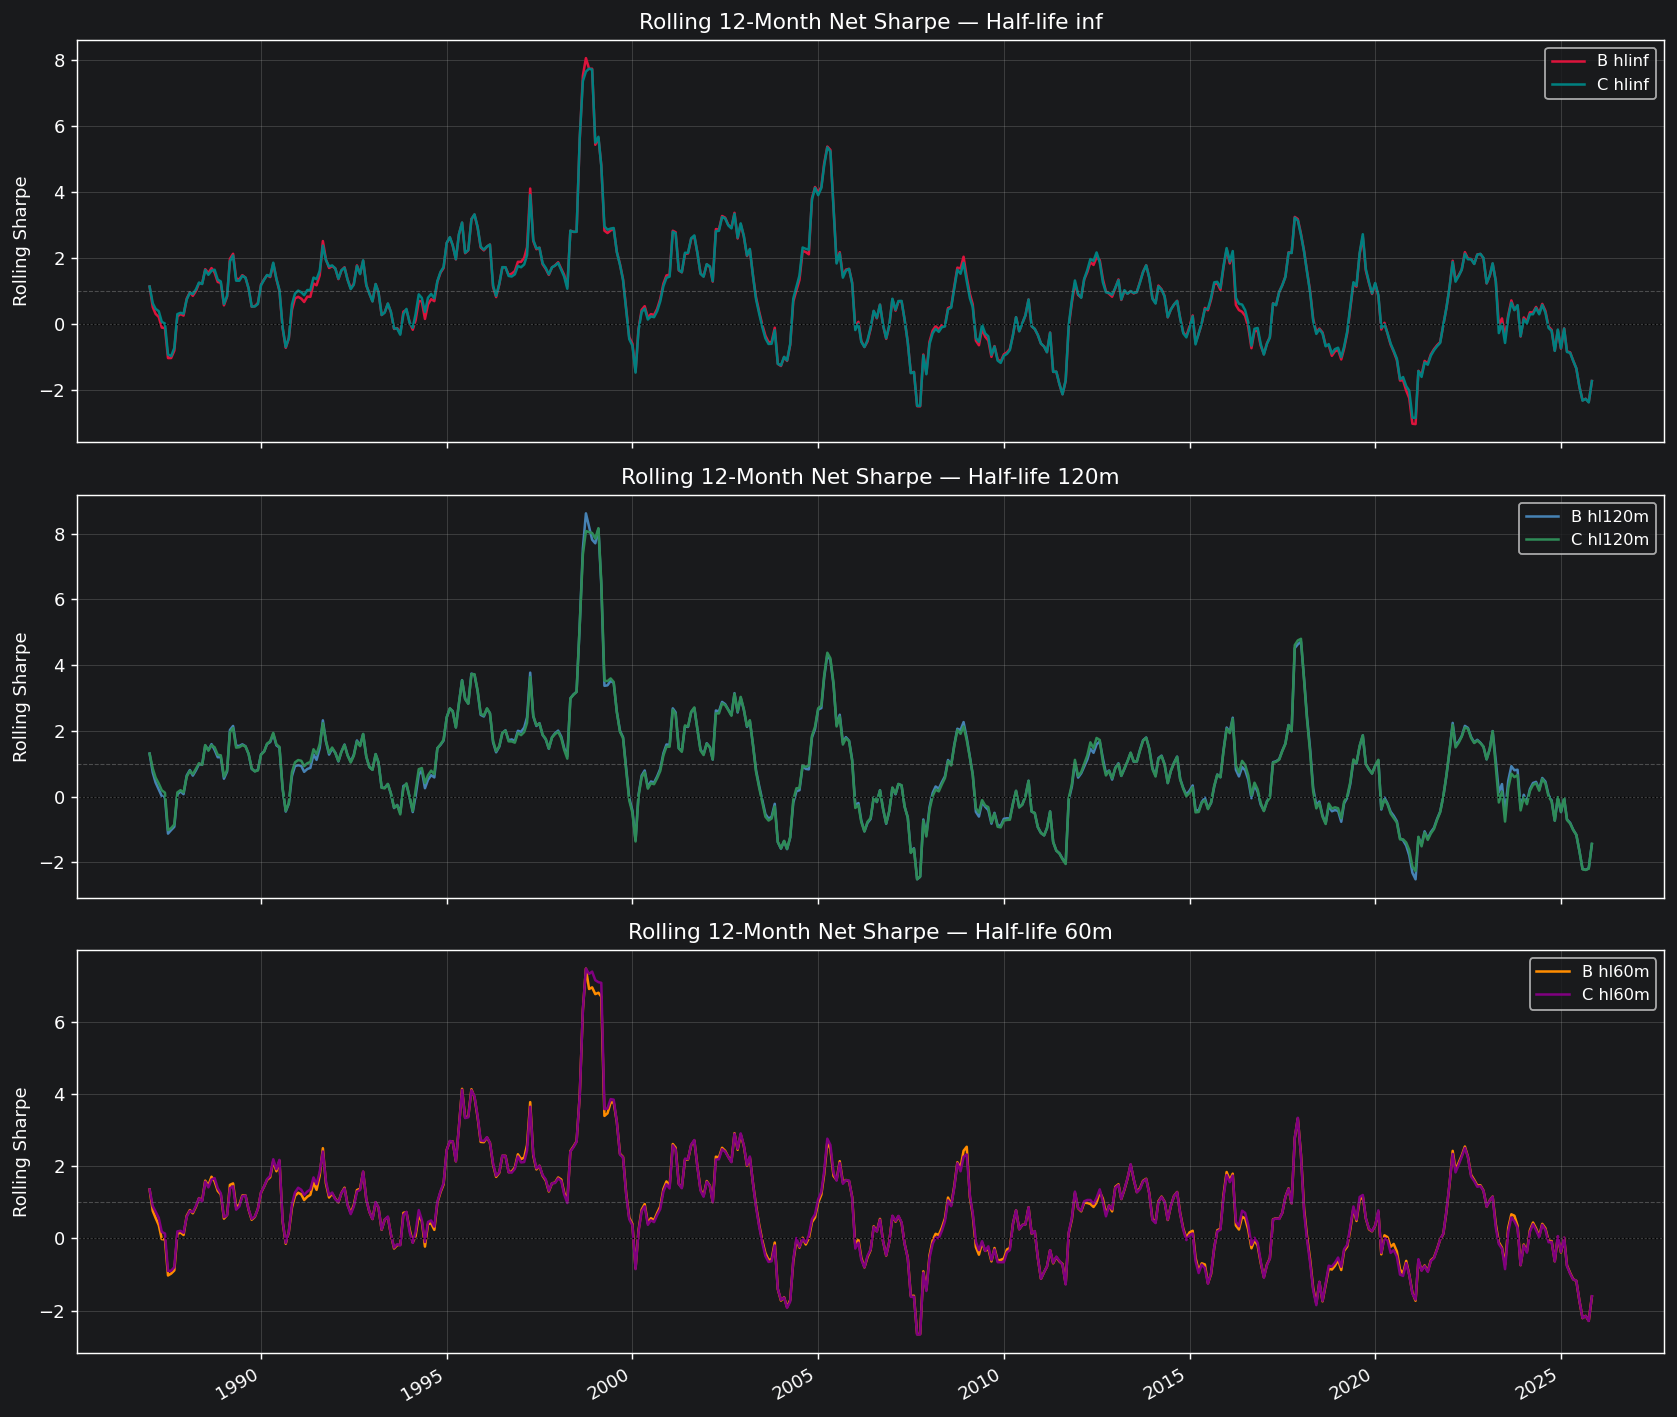

In [267]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

def rolling_sr(s, w=12):
    r = s.rolling(w)
    std = r.std()
    return np.where(std > 0, r.mean() / std * np.sqrt(12), np.nan)

for ax, (B, C, hl, ca, cb) in zip(axes, [
    (Binf, Cinf, "inf",  "crimson",    "teal"),
    (B120, C120, "120m", "steelblue",  "seagreen"),
    (B60,  C60,  "60m",  "darkorange", "purple"),
]):
    idx = B.index
    ax.plot(idx, rolling_sr(B["net_qspread"]), label=f"B hl{hl}", lw=1.4, color=ca)
    ax.plot(idx, rolling_sr(C["net_qspread"]), label=f"C hl{hl}", lw=1.4, color=cb)
    ax.axhline(0, color="black", lw=0.8, ls=":")
    ax.axhline(1, color="gray",  lw=0.6, ls="--", alpha=0.5)
    ax.set_ylabel("Rolling Sharpe")
    ax.set_title(f"Rolling 12-Month Net Sharpe — Half-life {hl}")
    ax.legend(fontsize=9)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 5 · Information Coefficient (IC) over Time

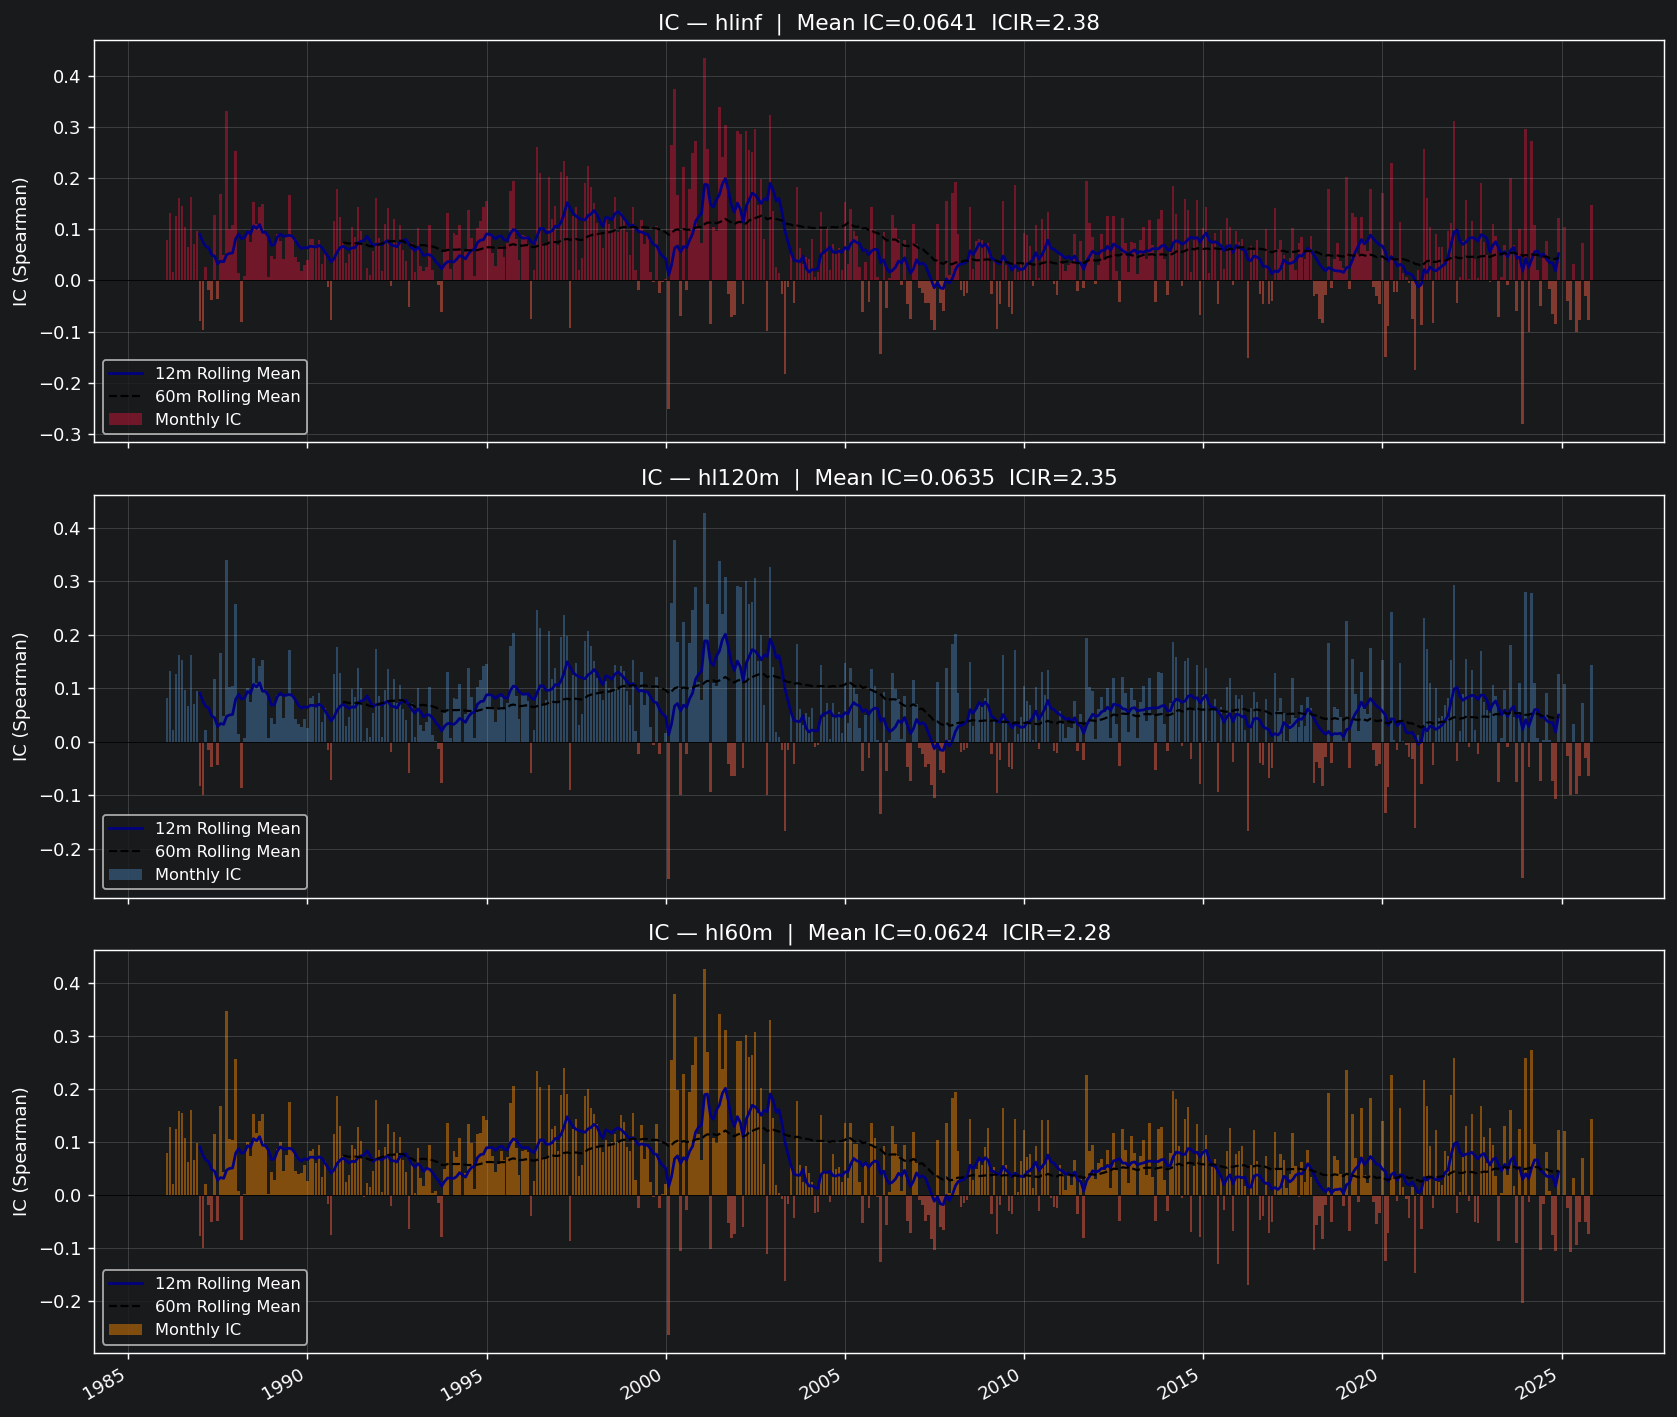

In [268]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

for ax, (df, hl, color) in zip(axes, [
    (Binf, "inf",  "crimson"),
    (B120, "120m", "steelblue"),
    (B60,  "60m",  "darkorange"),
]):
    ic = df["ic_spearman"]
    colors = [color if v >= 0 else "tomato" for v in ic.fillna(0)]
    ax.bar(ic.index, ic, width=25, color=colors, alpha=0.45, label="Monthly IC")
    ax.plot(ic.index, ic.rolling(12).mean(), color="navy", lw=1.5, label="12m Rolling Mean")
    ax.plot(ic.index, ic.rolling(60).mean(), color="black", lw=1.2, ls="--", label="60m Rolling Mean")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("IC (Spearman)")
    mu = ic.mean(); icir = mu / ic.std() * np.sqrt(12)
    ax.set_title(f"IC — hl{hl}  |  Mean IC={mu:.4f}  ICIR={icir:.2f}")
    ax.legend(fontsize=9)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 6 · IC Decay — Is the Signal Getting Weaker?

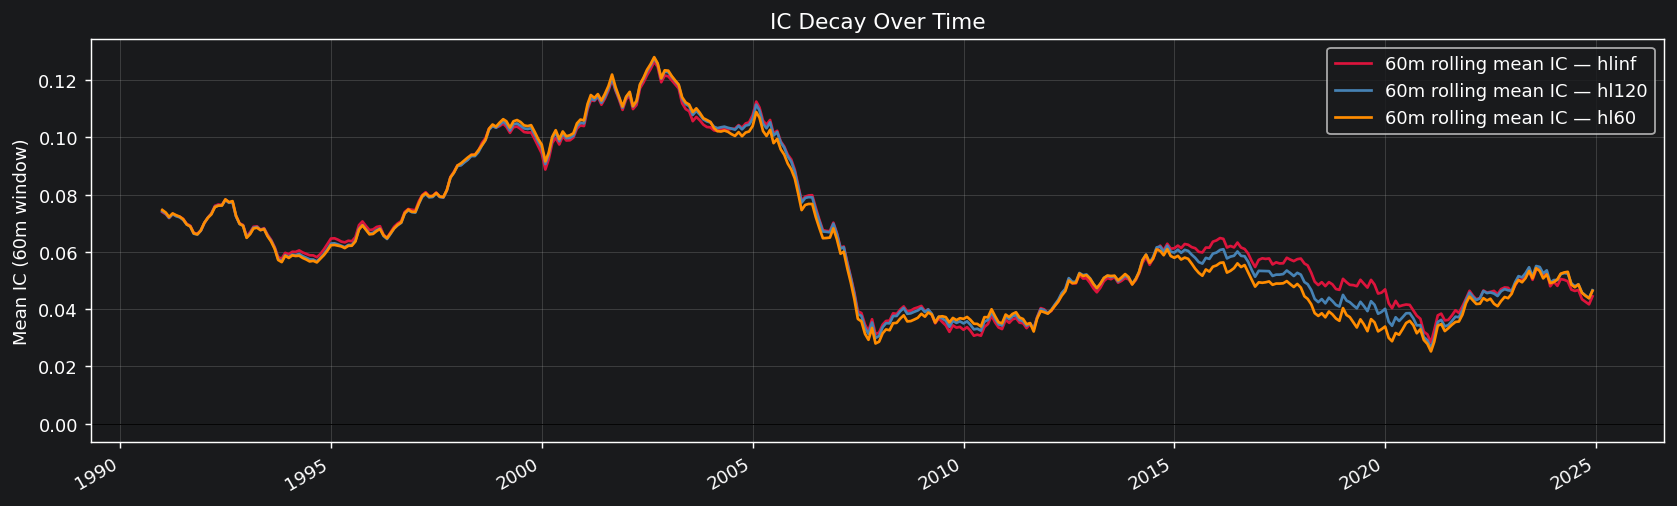

In [269]:
# 5-year rolling mean IC for each config
fig, ax = plt.subplots(figsize=(13, 4))
for df, label, color in [
    (Binf, "hlinf", "crimson"),
    (B120, "hl120", "steelblue"),
    (B60,  "hl60",  "darkorange"),
]:
    ic_5y = df["ic_spearman"].rolling(60).mean()
    ax.plot(df.index, ic_5y, label=f"60m rolling mean IC — {label}", lw=1.5, color=color)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Mean IC (60m window)")
ax.set_title("IC Decay Over Time")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 7 · Drawdown Analysis

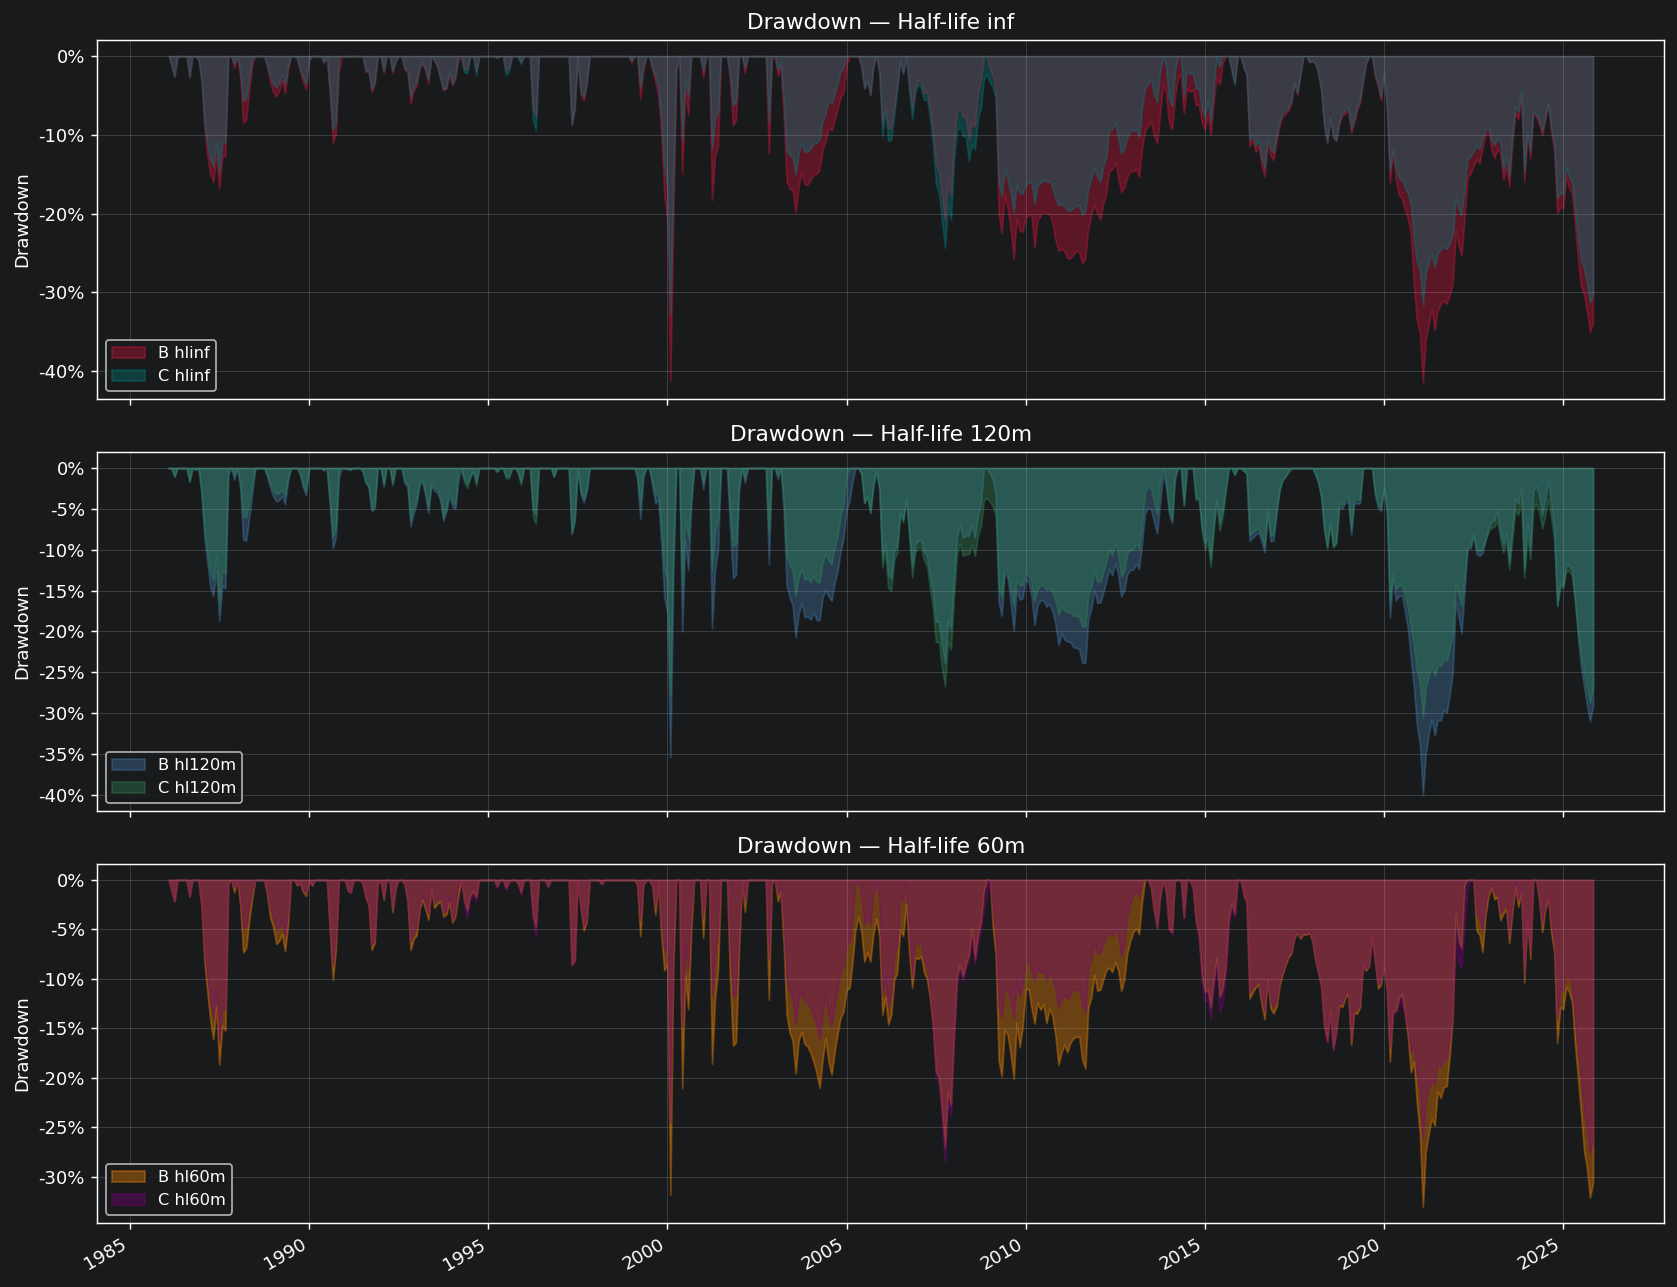

In [270]:
def drawdown(s):
    c = (1 + s.dropna()).cumprod()
    return (c - c.cummax()) / c.cummax()

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, (B, C, hl, ca, cb) in zip(axes, [
    (Binf, Cinf, "inf",  "crimson",    "teal"),
    (B120, C120, "120m", "steelblue",  "seagreen"),
    (B60,  C60,  "60m",  "darkorange", "purple"),
]):
    dd_B = drawdown(B["net_qspread"])
    dd_C = drawdown(C["net_qspread"])
    ax.fill_between(dd_B.index, dd_B, alpha=0.35, color=ca, label=f"B hl{hl}")
    ax.fill_between(dd_C.index, dd_C, alpha=0.35, color=cb, label=f"C hl{hl}")
    ax.set_ylabel("Drawdown")
    ax.set_title(f"Drawdown — Half-life {hl}")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(fontsize=9)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 8 · Monthly Return Distribution

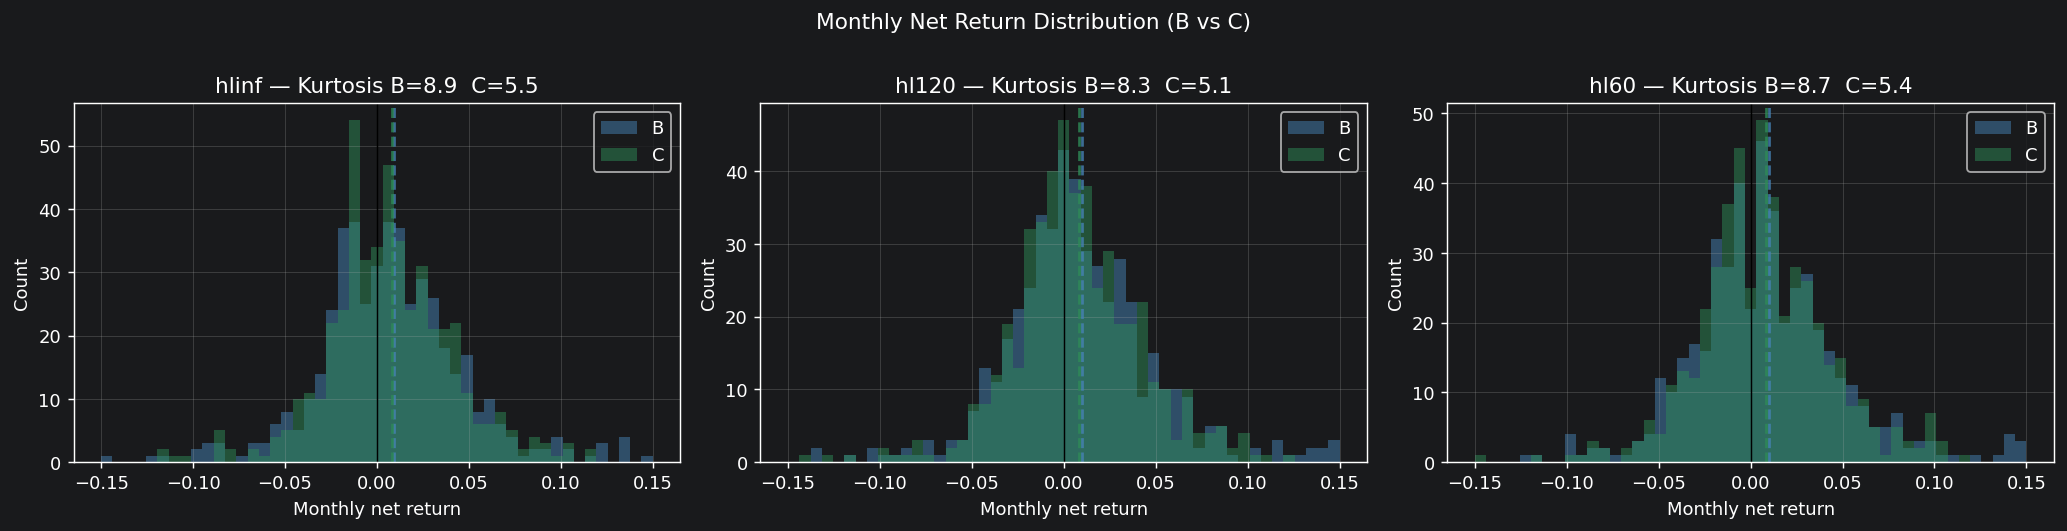

In [271]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (B, C, hl) in zip(axes, [
    (Binf, Cinf, "hlinf"),
    (B120, C120, "hl120"),
    (B60,  C60,  "hl60"),
]):
    bins = np.linspace(-0.15, 0.15, 50)
    ax.hist(B["net_qspread"].dropna(), bins=bins, alpha=0.5, label="B", color="steelblue")
    ax.hist(C["net_qspread"].dropna(), bins=bins, alpha=0.5, label="C", color="seagreen")
    ax.axvline(0, color="black", lw=0.8)
    for df, col in [(B, "steelblue"), (C, "seagreen")]:
        ax.axvline(df["net_qspread"].mean(), color=col, lw=1.5, ls="--", alpha=0.8)
    ax.set_xlabel("Monthly net return")
    ax.set_ylabel("Count")
    b_kurt = B["net_qspread"].dropna().kurt()
    c_kurt = C["net_qspread"].dropna().kurt()
    ax.set_title(f"{hl} — Kurtosis B={b_kurt:.1f}  C={c_kurt:.1f}")
    ax.legend()

fig.suptitle("Monthly Net Return Distribution (B vs C)", y=1.01)
fig.tight_layout()
plt.show()

## 9 · Turnover

hlinf  |  B median turnover: 1.334  C median turnover: 1.202
hl120m  |  B median turnover: 1.318  C median turnover: 1.182
hl60m  |  B median turnover: 1.307  C median turnover: 1.156


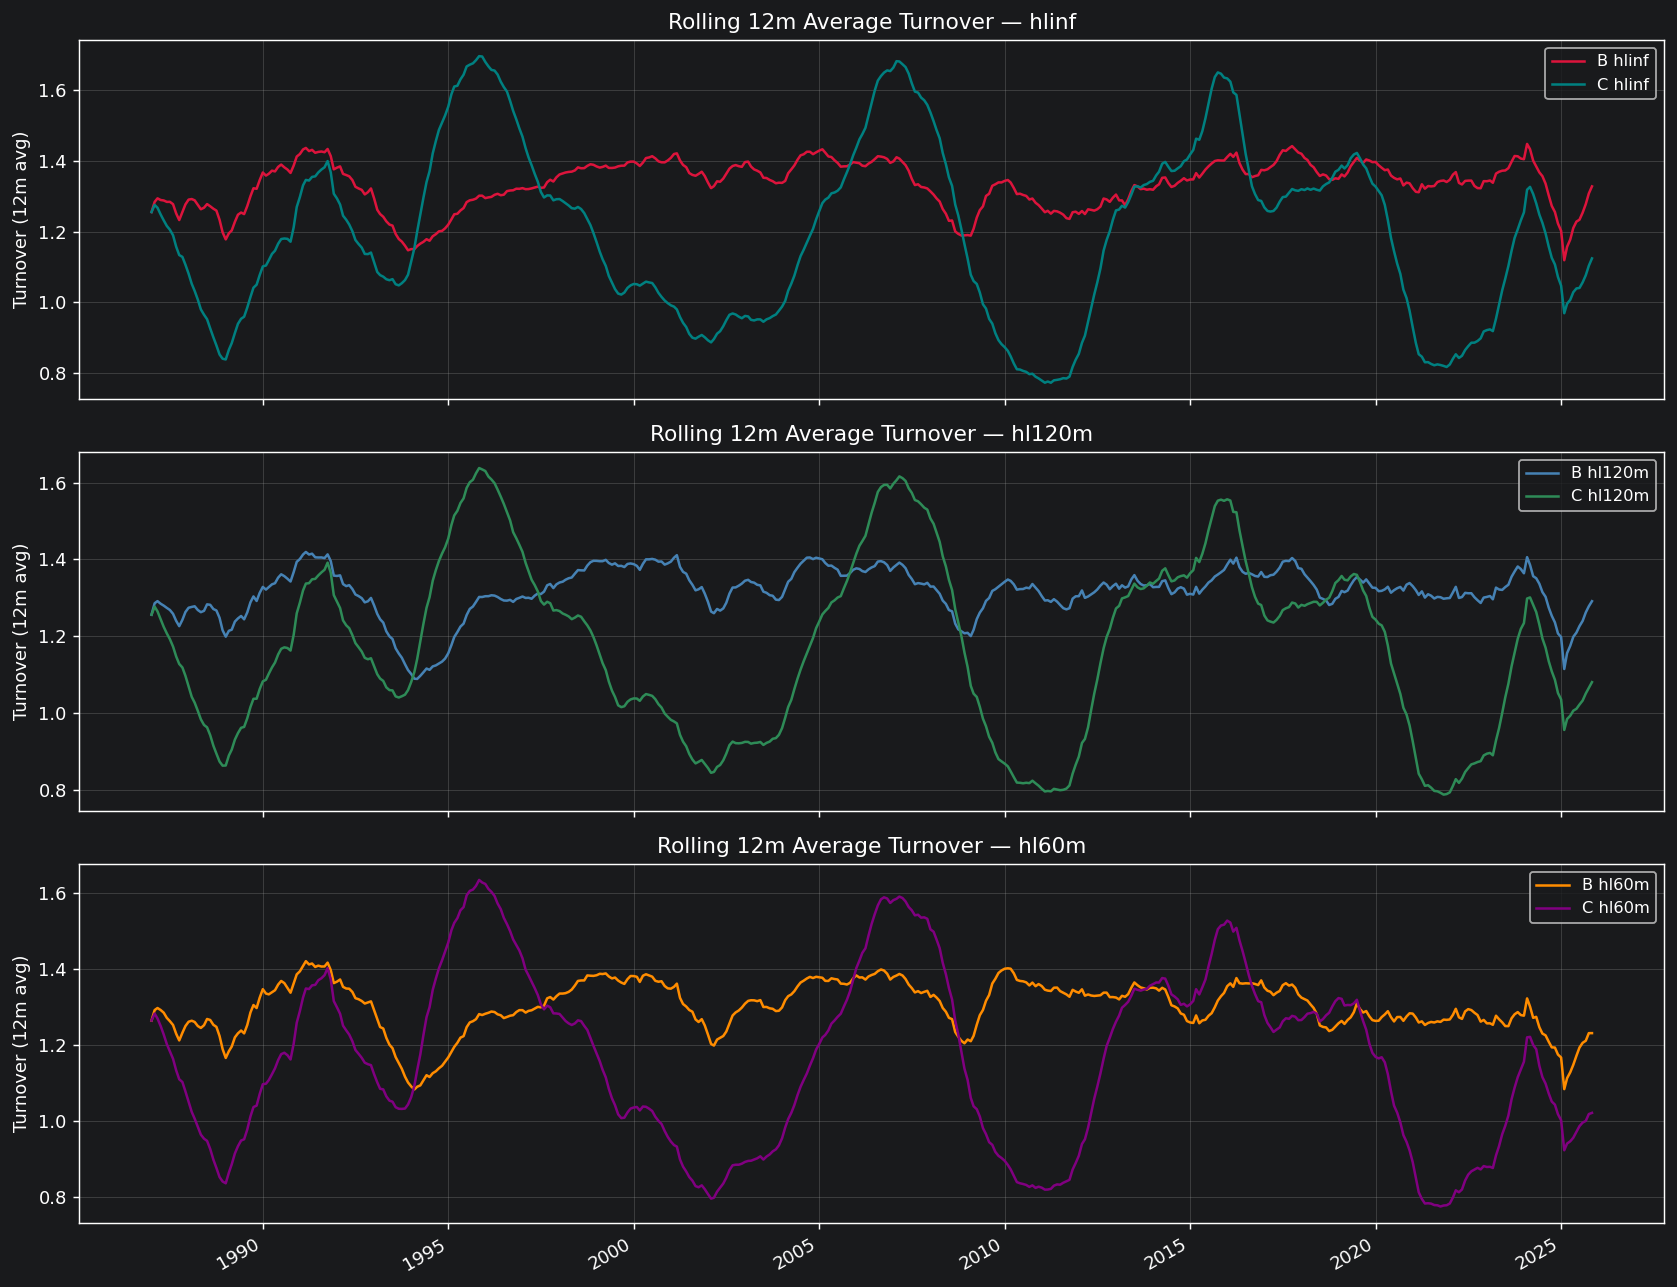

In [272]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, (B, C, hl, ca, cb) in zip(axes, [
    (Binf, Cinf, "inf",  "crimson",    "teal"),
    (B120, C120, "120m", "steelblue",  "seagreen"),
    (B60,  C60,  "60m",  "darkorange", "purple"),
]):
    ax.plot(B.index, B["turnover"].rolling(12).mean(), label=f"B hl{hl}", color=ca, lw=1.4)
    ax.plot(C.index, C["turnover"].rolling(12).mean(), label=f"C hl{hl}", color=cb, lw=1.4)
    ax.set_ylabel("Turnover (12m avg)")
    ax.set_title(f"Rolling 12m Average Turnover — hl{hl}")
    ax.legend(fontsize=9)
    print(f"hl{hl}  |  B median turnover: {B['turnover'].median():.3f}  "
          f"C median turnover: {C['turnover'].median():.3f}")

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 10 · Universe Size Over Time

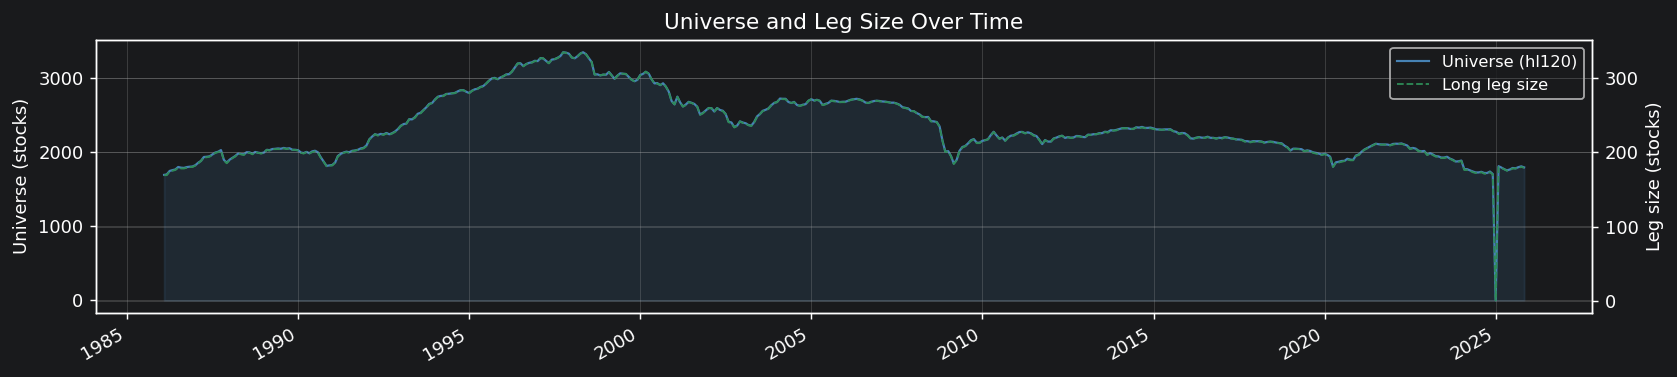

In [273]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(B120.index, B120["n_universe"], lw=1.2, color="steelblue", label="Universe (hl120)")
ax.fill_between(B120.index, B120["n_universe"], alpha=0.15, color="steelblue")
ax2 = ax.twinx()
ax2.plot(B120.index, B120["n_long"], lw=1.0, color="seagreen", ls="--", label="Long leg size")
ax.set_ylabel("Universe (stocks)")
ax2.set_ylabel("Leg size (stocks)")
ax.set_title("Universe and Leg Size Over Time")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 11 · Long / Short Leg Breakdown

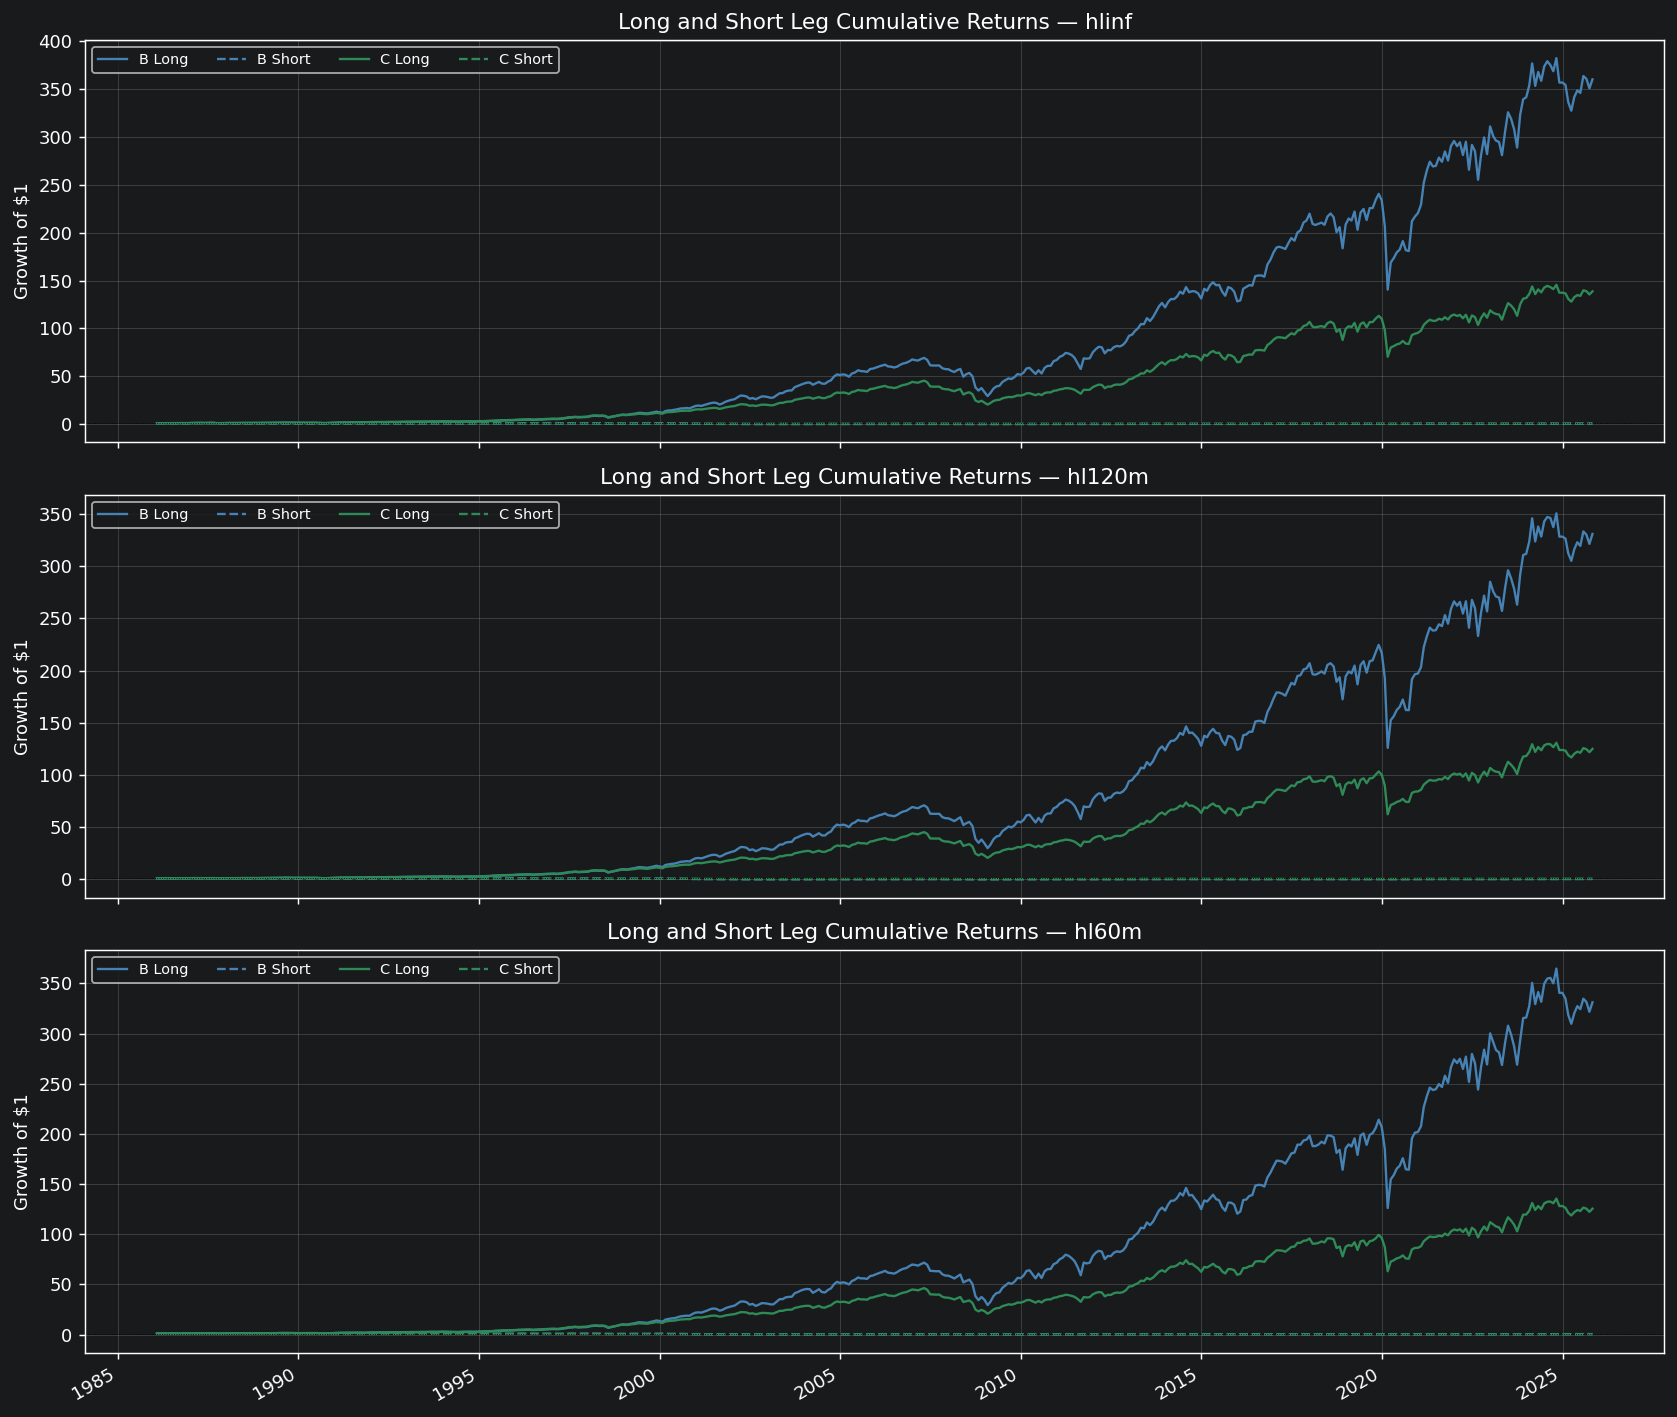

In [274]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

for ax, (B, C, hl) in zip(axes, [(Binf, Cinf, "inf"), (B120, C120, "120m"), (B60, C60, "60m")]):
    cum_long_B  = (1 + B["long_ret"].dropna()).cumprod()
    cum_short_B = (1 + B["short_ret"].dropna()).cumprod()
    cum_long_C  = (1 + C["long_ret"].dropna()).cumprod()
    cum_short_C = (1 + C["short_ret"].dropna()).cumprod()

    ax.plot(cum_long_B,  label="B Long",  lw=1.3, color="steelblue")
    ax.plot(cum_short_B, label="B Short", lw=1.3, color="steelblue", ls="--")
    ax.plot(cum_long_C,  label="C Long",  lw=1.3, color="seagreen")
    ax.plot(cum_short_C, label="C Short", lw=1.3, color="seagreen",  ls="--")
    ax.axhline(1, color="black", lw=0.5, ls=":")
    ax.set_ylabel("Growth of $1")
    ax.set_title(f"Long and Short Leg Cumulative Returns — hl{hl}")
    ax.legend(fontsize=8, ncol=4)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 12 · Best Config Recommendation

In [275]:
# Compare on last 10 years (120 months) — the honest forward-looking proxy
candidates = {
    "B hlinf": Binf["net_qspread"],
    "C hlinf": Cinf["net_qspread"],
    "B hl120": B120["net_qspread"],
    "C hl120": C120["net_qspread"],
    "B hl60":  B60["net_qspread"],
    "C hl60":  C60["net_qspread"],
}

print("=" * 55)
print(f"{'Config':<14} {'Full SR':>9} {'Last-10y SR':>12} {'Last-10y ret':>14}")
print("=" * 55)
for name, s in candidates.items():
    full  = s.dropna()
    last  = s.dropna().iloc[-120:]
    full_sr  = full.mean() / full.std() * np.sqrt(12)
    last_sr  = last.mean() / last.std() * np.sqrt(12)
    last_ret = last.mean() * 12
    print(f"{name:<14} {full_sr:>9.3f} {last_sr:>12.3f} {last_ret:>14.2%}")
print("=" * 55)
print("\nPick the config with the best LAST-10-YEAR Sharpe.")
print("If hlinf wins → equal-weight history best in current regime.")
print("If hl60 wins → 5y recency better captures current regime.")
print("If hl120 wins → 10y recency is sufficient / hl60 overfit.")

Config           Full SR  Last-10y SR   Last-10y ret
B hlinf            0.645       -0.110         -1.44%
C hlinf            0.695       -0.109         -1.18%
B hl120            0.675        0.011          0.15%
C hl120            0.722        0.007          0.08%
B hl60             0.664       -0.069         -0.90%
C hl60             0.697       -0.111         -1.19%

Pick the config with the best LAST-10-YEAR Sharpe.
If hlinf wins → equal-weight history best in current regime.
If hl60 wins → 5y recency better captures current regime.
If hl120 wins → 10y recency is sufficient / hl60 overfit.


## 13 · Market Alpha (CAPM Regression)

In [276]:
from scipy import stats

def capm_alpha(strategy_ret, market_ret, label=""):
    """OLS: r_strategy = alpha + beta * r_market + eps"""
    df = pd.concat([strategy_ret.rename("strat"), market_ret.rename("mkt")],
                   axis=1).dropna()
    slope, intercept, r, p, se = stats.linregress(df["mkt"], df["strat"])
    n        = len(df)
    alpha_m  = intercept
    alpha_a  = intercept * 12
    residuals = df["strat"] - (intercept + slope * df["mkt"])
    s2        = residuals.var(ddof=2)
    x_bar     = df["mkt"].mean()
    sxx       = ((df["mkt"] - x_bar) ** 2).sum()
    se_int    = np.sqrt(s2 * (1/n + x_bar**2 / sxx))
    t_alpha   = alpha_m / se_int
    p_alpha   = 2 * stats.t.sf(abs(t_alpha), df=n - 2)
    return {
        "label":      label,
        "alpha_ann":  alpha_a,
        "beta":       slope,
        "t_alpha":    t_alpha,
        "p_alpha":    p_alpha,
        "r_squared":  r ** 2,
        "n":          n,
    }

mkt = MKT["mkt_vw_lcl"]

results = [
    capm_alpha(Binf["net_qspread"], mkt, "B hlinf"),
    capm_alpha(Cinf["net_qspread"], mkt, "C hlinf"),
    capm_alpha(B120["net_qspread"], mkt, "B hl120"),
    capm_alpha(C120["net_qspread"], mkt, "C hl120"),
    capm_alpha(B60["net_qspread"],  mkt, "B hl60"),
    capm_alpha(C60["net_qspread"],  mkt, "C hl60"),
]
alpha_tbl = pd.DataFrame(results).set_index("label")
out = alpha_tbl.copy()
out["alpha_ann"] = out["alpha_ann"].map("{:.2%}".format)
out["beta"]      = out["beta"].map("{:.4f}".format)
out["t_alpha"]   = out["t_alpha"].map("{:.2f}".format)
out["p_alpha"]   = out["p_alpha"].map("{:.4f}".format)
out["r_squared"] = out["r_squared"].map("{:.4f}".format)
out["n"]         = out["n"].map("{:.0f}".format)
print("CAPM Alpha (regress net Q-spread on market VW return)\n")
print(out.to_string())
print("\nNote: beta ≈ 0 confirms the spread is market-neutral.")
print("      |t_alpha| > 2 → alpha is statistically significant at 5%.")

CAPM Alpha (regress net Q-spread on market VW return)

        alpha_ann     beta t_alpha p_alpha r_squared    n
label                                                    
B hlinf    12.25%  -0.0679    4.27  0.0000    0.0036  478
C hlinf    10.47%  -0.0565    4.59  0.0000    0.0040  478
B hl120    12.64%  -0.0481    4.36  0.0000    0.0018  478
C hl120    10.70%  -0.0390    4.65  0.0000    0.0019  478
B hl60     12.57%  -0.0345    4.23  0.0000    0.0009  478
C hl60     10.42%  -0.0299    4.44  0.0000    0.0011  478

Note: beta ≈ 0 confirms the spread is market-neutral.
      |t_alpha| > 2 → alpha is statistically significant at 5%.
